# 🚀 PROJECT: THE MRIDANSH
# CENTRAL ENGINE: AETHER-MRID1607X
## Multi-Domain Soil Intelligence Engine (Agronomy & Geotechnical Stability)
**Division:** RS-SDA Division | JCC Campus 2  
**Core Framework:** Independent Generalization, Spatial/Temporal Holdouts & Baseline Evaluation  

---

# 🔬 Notebook 11: Generalization & Baseline Evaluation Engine
**Sprint Phase:** Day 13 / 18-Day Scientific Audit & Validation Mission  
**Execution Objective:** Scientifically test whether MRIDANSH performance gains survive under independent spatial separation, future temporal holdouts, and Leave-One-Component-Out (LOCO) stress tests, comparing the locked architecture against competitive baseline models.


# 🛰️ Notebook 11: Generalization & Baseline Evaluation (Empirical Engine)

---
### 🔒 SCIENTIFIC INTEGRITY RULES
1. No ground-truth-derived predictions or synthetic noise injection.
2. No manually prescribed RMSE penalties or simulated LOCO drops.
3. No manually prescribed uncertainty values or circular error dependencies.
4. No test-set tuning or re-training post-evaluation.
5. No fitting scalers on the complete dataset (Fit strictly on `X_train`).
6. No future temporal leakage across splits.
7. No spatial test leakage between blocks.
8. No predetermined module essentiality assumptions.
9. Synthetic HSI results must never be presented as real-world validation.
10. All reported metrics must originate from actual model predictions.
---


In [15]:
# ==============================================================================
# CELL 1: SETUP, COHERENT GENERATOR & FROZEN INDEX SPLITS WITH DIAGNOSTICS
# ==============================================================================
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

plt.style.use('dark_background')

SEEDS = [42, 101, 2024]
PRIMARY_SEED = SEEDS[0]

def generate_coherent_mridansh_dataset(n_samples=2500, seed=42):
    np.random.seed(seed)
    lats = np.random.uniform(20.0, 22.0, n_samples)
    lons = np.random.uniform(77.0, 79.0, n_samples)
    
    lat_bins = np.digitize(lats, bins=np.linspace(20.0, 22.0, 6)) - 1
    lon_bins = np.digitize(lons, bins=np.linspace(77.0, 79.0, 6)) - 1
    spatial_block_ids = lat_bins * 5 + lon_bins

    doys = np.random.randint(1, 366, n_samples)
    years = np.random.choice([2024, 2025], size=n_samples, p=[0.5, 0.5])
    
    elevation = np.random.uniform(200.0, 800.0, n_samples)
    slope = np.random.uniform(0.0, 30.0, n_samples)
    
    temp = 15.0 + 15.0 * np.sin(2 * np.pi * (doys - 80) / 365.0) + np.random.normal(0, 2.0, n_samples)
    precip = np.maximum(0, np.random.exponential(scale=5.0, size=n_samples) * (np.sin(2 * np.pi * (doys - 150) / 365.0) + 1.0))
    
    base_retention = 0.25
    dem_effect = -0.0001 * (elevation - 200) - 0.003 * slope
    weather_effect = 0.008 * precip - 0.004 * (temp - 15)
    seasonal_effect = 0.05 * np.sin(2 * np.pi * doys / 365.0)
    
    theta_true = base_retention + dem_effect + weather_effect + seasonal_effect
    theta_true = np.clip(theta_true + np.random.normal(0, 0.01, n_samples), 0.05, 0.45)
    
    vv = -18.0 + 25.0 * theta_true + np.random.normal(0, 0.5, n_samples)
    vh = -24.0 + 20.0 * theta_true + np.random.normal(0, 0.5, n_samples)
    ndvi = 0.2 + 0.8 * theta_true + np.random.normal(0, 0.03, n_samples)
    ndwi = -0.3 + 1.2 * theta_true + np.random.normal(0, 0.03, n_samples)
    
    hsi_1400 = 0.8 - 1.1 * theta_true + np.random.normal(0, 0.01, n_samples)
    hsi_1900 = 0.7 - 0.9 * theta_true + np.random.normal(0, 0.01, n_samples)
    hsi_synth = np.column_stack([hsi_1400, hsi_1900] + [np.random.normal(0.5, 0.1, n_samples) for _ in range(8)])
    
    df = pd.DataFrame({
        'latitude': lats,
        'longitude': lons,
        'spatial_block': spatial_block_ids,
        'doy': doys,
        'year': years,
        'S1_VV': vv,
        'S1_VH': vh,
        'S2_NDVI': ndvi,
        'S2_NDWI': ndwi,
        'DEM_elevation': elevation,
        'DEM_slope': slope,
        'Weather_precip': precip,
        'Weather_temp': temp,
        'theta_target': theta_true
    })
    
    for b in range(10):
        df[f'HSI_band_{b+1}'] = hsi_synth[:, b]
        
    return df

df_eval = generate_coherent_mridansh_dataset(n_samples=2500, seed=PRIMARY_SEED)

feature_cols = {
    'S2': ['S2_NDVI', 'S2_NDWI'],
    'S1': ['S1_VV', 'S1_VH'],
    'DEM': ['DEM_elevation', 'DEM_slope'],
    'Weather': ['Weather_precip', 'Weather_temp'],
    'Temporal': ['doy'],
    'HSI': [f'HSI_band_{b+1}' for b in range(10)]
}

all_base_features = feature_cols['S2'] + feature_cols['S1'] + feature_cols['DEM'] + feature_cols['Weather'] + feature_cols['Temporal']
all_hsi_features = all_base_features + feature_cols['HSI']

def create_frozen_index_splits(df, seed=42):
    np.random.seed(seed)
    n_samples = len(df)
    
    masks = {
        'Regime A (IID)': np.random.rand(n_samples) > 0.80,
        'Regime B (Spatial OOD)': df['spatial_block'].isin([20, 21, 22, 23, 24]).values,
        'Regime C (Temporal OOD)': (df['year'] == 2025).values,
        'Regime D (Spatio-Temp OOD)': (df['spatial_block'].isin([20, 21, 22, 23, 24]) & (df['year'] == 2025)).values
    }
    
    frozen_splits = {}
    for r_name, test_mask in masks.items():
        test_idx = df.index[test_mask].values
        train_val_idx = df.index[~test_mask].values
        
        n_val = int(len(train_val_idx) * 0.15)
        val_idx = np.random.choice(train_val_idx, size=n_val, replace=False)
        train_idx = np.setdiff1d(train_val_idx, val_idx)
        
        frozen_splits[r_name] = {
            'train': train_idx,
            'val': val_idx,
            'test': test_idx
        }
    return frozen_splits

frozen_splits = create_frozen_index_splits(df_eval, seed=PRIMARY_SEED)

def get_scaled_splits_by_index(df, split_dict, feature_list):
    """SINGLE UNIFIED DATA SCALER AND EXTRACTOR (No Duplicates)"""
    train_idx, val_idx, test_idx = split_dict['train'], split_dict['val'], split_dict['test']
    
    X_tr_raw = df.loc[train_idx, feature_list].values
    y_tr = df.loc[train_idx, 'theta_target'].values
    
    X_val_raw = df.loc[val_idx, feature_list].values
    y_val = df.loc[val_idx, 'theta_target'].values
    
    X_te_raw = df.loc[test_idx, feature_list].values
    y_te = df.loc[test_idx, 'theta_target'].values
    
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr_raw)
    X_val = scaler.transform(X_val_raw)
    X_te = scaler.transform(X_te_raw)
    
    return X_tr, y_tr, X_val, y_val, X_te, y_te

def compute_distribution_shift_diagnostics(df, frozen_splits, feature_cols):
    tr_idx = frozen_splits['Regime A (IID)']['train']
    st_ood_idx = frozen_splits['Regime D (Spatio-Temp OOD)']['test']
    
    shift_results = []
    for feat in feature_cols:
        tr_val = df.loc[tr_idx, feat].values
        ood_val = df.loc[st_ood_idx, feat].values
        
        ks_stat, p_val = stats.ks_2samp(tr_val, ood_val)
        w_dist = stats.wasserstein_distance(tr_val, ood_val)
        
        shift_results.append({
            'Feature': feat,
            'KS-Statistic': f"{ks_stat:.4f}",
            'p-value': f"{p_val:.2e}",
            'Wasserstein Distance': f"{w_dist:.4f}",
            'Shift Severity': 'High Shift' if ks_stat > 0.2 else 'Moderate Shift' if ks_stat > 0.1 else 'Low Shift'
        })
        
    return pd.DataFrame(shift_results)

df_shift_diag = compute_distribution_shift_diagnostics(df_eval, frozen_splits, all_base_features)

print("=========================================================================================================")
print("  🔍 DIAGNOSTICS: IID vs SPATIO-TEMPORAL OOD DISTRIBUTION SHIFT MATRIX")
print("=========================================================================================================")
print(df_shift_diag.to_string(index=False))
print("=========================================================================================================")

  🔍 DIAGNOSTICS: IID vs SPATIO-TEMPORAL OOD DISTRIBUTION SHIFT MATRIX
       Feature KS-Statistic  p-value Wasserstein Distance Shift Severity
       S2_NDVI       0.0636 2.83e-01               0.0051      Low Shift
       S2_NDWI       0.0518 5.34e-01               0.0087      Low Shift
         S1_VV       0.0539 4.82e-01               0.1992      Low Shift
         S1_VH       0.0645 2.68e-01               0.1417      Low Shift
 DEM_elevation       0.0552 4.53e-01               9.2169      Low Shift
     DEM_slope       0.0442 7.30e-01               0.4344      Low Shift
Weather_precip       0.0567 4.18e-01               0.4365      Low Shift
  Weather_temp       0.0386 8.60e-01               0.4817      Low Shift
           doy       0.0310 9.71e-01               3.5107      Low Shift


## 📐 Model Architecture & Real EnKF Assimilation Formalism

### 1. Neural Architectures
* **`MultimodalBaselineMLP`:** Multimodal baseline network without physical soft-penalties.
* **`MRIDANSHCoreNet`:** Physics-regularized deep network employing SiLU activations and a mass-conservation constraint ($\theta \in [0.0, 0.6]$).

### 2. Real EnKF Innovation State Analysis Update
Given $N$ ensemble model forecasts $\mathbf{x}_f^{(i)}$ and synthetic observations $\mathbf{y}$ with variance $R$:

1. **Prior Mean & Variance:**
   $$\bar{\mathbf{x}}_f = \frac{1}{N}\sum_{i=1}^N \mathbf{x}_f^{(i)}, \quad \mathbf{P}_f = \text{Var}(\mathbf{x}_f) + \epsilon$$

2. **Kalman Gain Matrix:**
   $$\mathbf{K} = \frac{\mathbf{P}_f}{\mathbf{P}_f + R}$$

3. **Posterior State Analysis Update:**
   $$\mathbf{x}_a = \bar{\mathbf{x}}_f + \mathbf{K} \cdot (\mathbf{y} - \bar{\mathbf{x}}_f), \quad \mathbf{P}_a = (1 - \mathbf{K})\mathbf{P}_f, \quad \sigma = \sqrt{\mathbf{P}_a}$$

In [16]:
# ==============================================================================
# CELL 2: MODEL DEFINITIONS, DEEPCOPY TRAINER & REAL ENKF INNOVATION UPDATE
# ==============================================================================

class MultimodalBaselineMLP(nn.Module):
    def __init__(self, input_dim):
        super(MultimodalBaselineMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

class MRIDANSHCoreNet(nn.Module):
    def __init__(self, input_dim):
        super(MRIDANSHCoreNet, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.SiLU(),
            nn.Linear(64, 32),
            nn.SiLU()
        )
        self.head = nn.Linear(32, 1)
        
    def forward(self, x):
        return self.head(self.encoder(x))

def train_pytorch_model_with_early_stopping(model, X_train, y_train, X_val, y_val, 
                                           max_epochs=150, lr=0.005, patience=15, physics_weight=0.0):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    X_tr_t = torch.tensor(X_train, dtype=torch.float32)
    y_tr_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
    X_val_t = torch.tensor(X_val, dtype=torch.float32)
    y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)
    
    best_val_loss = float('inf')
    best_weights = None
    patience_counter = 0
    
    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        preds = model(X_tr_t)
        loss = criterion(preds, y_tr_t)
        
        if physics_weight > 0.0:
            phys_penalty = torch.mean(torch.relu(-preds) + torch.relu(preds - 0.6))
            loss += physics_weight * phys_penalty
            
        loss.backward()
        optimizer.step()
        
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), y_val_t).item()
            
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            # Safe Deepcopy of State Weights
            best_weights = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break
                
    if best_weights is not None:
        model.load_state_dict(best_weights)
        
    return model

def real_enkf_assimilation_update(ensemble_forecasts, observations, R_obs_var=0.001):
    """
    True Ensemble Kalman Filter (EnKF) Observation Analysis Update:
    x_a = x_f + K * (y - H*x_f)
    K = P_f / (P_f + R)
    """
    N_ens, N_obs = ensemble_forecasts.shape
    
    x_f = np.mean(ensemble_forecasts, axis=0)
    P_f = np.var(ensemble_forecasts, axis=0) + 1e-6
    
    # Kalman Gain
    K = P_f / (P_f + R_obs_var)
    
    # Innovation step
    innovation = observations - x_f
    x_analysis = x_f + K * innovation
    
    P_analysis = (1.0 - K) * P_f
    sigma_posterior = np.sqrt(np.maximum(P_analysis, 1e-8))
    
    return x_analysis, sigma_posterior

print("✅ Models, Deepcopy Trainer, and Real EnKF Update Engine Initialized!")

✅ Models, Deepcopy Trainer, and Real EnKF Update Engine Initialized!


## 📊 Table 1: Multi-Regime Generalization Matrix

Evaluates performance across 4 generalization regimes averaged over 3 random seeds ($\text{mean} \pm \text{std}$):
* **Regime A:** Random-IID Baseline
* **Regime B:** Spatial Out-Of-Domain (Block spatial holdout)
* **Regime C:** Temporal Out-Of-Domain (2025 Year holdout)
* **Regime D:** Spatio-Temporal Out-Of-Domain (Block + Year holdout)

In [17]:
# ==============================================================================
# CELL 3: MULTI-SEED MULTI-REGIME EXECUTION & TABLE 1 GENERATION (3 SEEDS)
# ==============================================================================

model_names = ['S2 Simple', 'Classical ML (RF)', 'Multimodal Baseline MLP', 'MRIDANSH-Core', 'MRIDANSH + HSI']
regime_names = list(frozen_splits.keys())

seed_regime_results = {m: {r: [] for r in regime_names} for m in model_names}

for s_idx, seed in enumerate(SEEDS):
    np.random.seed(seed)
    torch.manual_seed(seed)
    df_s = generate_coherent_mridansh_dataset(n_samples=2500, seed=seed)
    splits_s = create_frozen_index_splits(df_s, seed=seed)
    
    for r_name in regime_names:
        split_dict = splits_s[r_name]
        
        # 1. S2 Simple
        X_tr, y_tr, X_val, y_val, X_te, y_te = get_scaled_splits_by_index(df_s, split_dict, feature_cols['S2'])
        m1 = Ridge(alpha=1.0).fit(X_tr, y_tr)
        seed_regime_results['S2 Simple'][r_name].append(np.sqrt(mean_squared_error(y_te, m1.predict(X_te))))
        
        # 2. Random Forest
        X_tr, y_tr, X_val, y_val, X_te, y_te = get_scaled_splits_by_index(df_s, split_dict, all_base_features)
        m2 = RandomForestRegressor(n_estimators=50, random_state=seed).fit(X_tr, y_tr)
        seed_regime_results['Classical ML (RF)'][r_name].append(np.sqrt(mean_squared_error(y_te, m2.predict(X_te))))
        
        # 3. Multimodal Baseline MLP
        m3 = MultimodalBaselineMLP(input_dim=X_tr.shape[1])
        m3 = train_pytorch_model_with_early_stopping(m3, X_tr, y_tr, X_val, y_val, physics_weight=0.0)
        m3.eval()
        with torch.no_grad():
            p3 = m3(torch.tensor(X_te, dtype=torch.float32)).numpy().flatten()
        seed_regime_results['Multimodal Baseline MLP'][r_name].append(np.sqrt(mean_squared_error(y_te, p3)))
        
        # 4. MRIDANSH-Core
        m4 = MRIDANSHCoreNet(input_dim=X_tr.shape[1])
        m4 = train_pytorch_model_with_early_stopping(m4, X_tr, y_tr, X_val, y_val, physics_weight=0.1)
        m4.eval()
        with torch.no_grad():
            p4 = m4(torch.tensor(X_te, dtype=torch.float32)).numpy().flatten()
        seed_regime_results['MRIDANSH-Core'][r_name].append(np.sqrt(mean_squared_error(y_te, p4)))
        
        # 5. MRIDANSH + HSI
        X_tr_h, y_tr_h, X_val_h, y_val_h, X_te_h, y_te_h = get_scaled_splits_by_index(df_s, split_dict, all_hsi_features)
        m5 = MRIDANSHCoreNet(input_dim=X_tr_h.shape[1])
        m5 = train_pytorch_model_with_early_stopping(m5, X_tr_h, y_tr_h, X_val_h, y_val_h, physics_weight=0.1)
        m5.eval()
        with torch.no_grad():
            p5 = m5(torch.tensor(X_te_h, dtype=torch.float32)).numpy().flatten()
        seed_regime_results['MRIDANSH + HSI'][r_name].append(np.sqrt(mean_squared_error(y_te_h, p5)))

table1_rows = []
for m in model_names:
    row = {'Model': m}
    for r in regime_names:
        arr = np.array(seed_regime_results[m][r])
        row[r] = f"{np.mean(arr):.5f} ± {np.std(arr):.5f}"
        
    iid_arr = np.array(seed_regime_results[m]['Regime A (IID)'])
    st_arr = np.array(seed_regime_results[m]['Regime D (Spatio-Temp OOD)'])
    gap_arr = st_arr - iid_arr
    row['Generalization Gap (D - A)'] = f"{np.mean(gap_arr):+.5f} ± {np.std(gap_arr):.5f}"
    table1_rows.append(row)

df_table1_final = pd.DataFrame(table1_rows)

print("=========================================================================================================")
print("  📊 TABLE 1 - MULTI-REGIME GENERALIZATION MATRIX (MEAN ± STD OVER 3 SEEDS)")
print("=========================================================================================================")
print(df_table1_final.to_string(index=False))
print("=========================================================================================================")

  📊 TABLE 1 - MULTI-REGIME GENERALIZATION MATRIX (MEAN ± STD OVER 3 SEEDS)
                  Model    Regime A (IID) Regime B (Spatial OOD) Regime C (Temporal OOD) Regime D (Spatio-Temp OOD) Generalization Gap (D - A)
              S2 Simple 0.01983 ± 0.00038      0.01984 ± 0.00039       0.01982 ± 0.00041          0.02039 ± 0.00049         +0.00056 ± 0.00037
      Classical ML (RF) 0.01249 ± 0.00015      0.01269 ± 0.00033       0.01320 ± 0.00027          0.01299 ± 0.00072         +0.00051 ± 0.00060
Multimodal Baseline MLP 0.01322 ± 0.00201      0.01108 ± 0.00034       0.01422 ± 0.00276          0.01347 ± 0.00161         +0.00025 ± 0.00168
          MRIDANSH-Core 0.00981 ± 0.00026      0.00984 ± 0.00021       0.01009 ± 0.00045          0.01025 ± 0.00054         +0.00043 ± 0.00051
         MRIDANSH + HSI 0.00758 ± 0.00129      0.00684 ± 0.00053       0.00794 ± 0.00031          0.00683 ± 0.00076         -0.00075 ± 0.00204


## 📊 Table 2: Frozen Empirical LOCO Ablation Matrix

Calculates degradation metrics ($\Delta\text{RMSE}$) and uncertainty variation ($\Delta\sigma$) across component removals under frozen spatial and temporal index splits.

In [18]:
# ==============================================================================
# CELL 4: FROZEN LOCO MATRIX WITH REAL ENKF ANALYSIS & TABLE 2 OUTPUT
# ==============================================================================

loco_configs = {
    'S1 Radar': [c for c in all_hsi_features if not c.startswith('S1_')],
    'DEM Terrain': [c for c in all_hsi_features if not c.startswith('DEM_')],
    'Weather': [c for c in all_hsi_features if not c.startswith('Weather_')],
    'Temporal': [c for c in all_hsi_features if c != 'doy'],
    'HSI Spectral': all_base_features
}

spat_split = frozen_splits['Regime B (Spatial OOD)']
temp_split = frozen_splits['Regime C (Temporal OOD)']

X_tr_f, y_tr_f, X_val_f, y_val_f, X_te_spat_f, y_te_spat_f = get_scaled_splits_by_index(df_eval, spat_split, all_hsi_features)
_, _, _, _, X_te_temp_f, y_te_temp_f = get_scaled_splits_by_index(df_eval, temp_split, all_hsi_features)

N_ENSEMBLE = 5
full_ens_spat, full_ens_temp = [], []

for s in range(N_ENSEMBLE):
    torch.manual_seed(PRIMARY_SEED + s * 10)
    m = MRIDANSHCoreNet(input_dim=X_tr_f.shape[1])
    m = train_pytorch_model_with_early_stopping(m, X_tr_f, y_tr_f, X_val_f, y_val_f, physics_weight=0.1)
    m.eval()
    with torch.no_grad():
        full_ens_spat.append(m(torch.tensor(X_te_spat_f, dtype=torch.float32)).numpy().flatten())
        full_ens_temp.append(m(torch.tensor(X_te_temp_f, dtype=torch.float32)).numpy().flatten())

full_ens_spat = np.array(full_ens_spat)
full_ens_temp = np.array(full_ens_temp)

np.random.seed(PRIMARY_SEED)
obs_spat = y_te_spat_f + np.random.normal(0, 0.03, size=len(y_te_spat_f))
obs_temp = y_te_temp_f + np.random.normal(0, 0.03, size=len(y_te_temp_f))

# Real EnKF Observation Analysis Update
p_spat_enkf, sigma_spat_enkf = real_enkf_assimilation_update(full_ens_spat, obs_spat, R_obs_var=0.001)
p_temp_enkf, sigma_temp_enkf = real_enkf_assimilation_update(full_ens_temp, obs_temp, R_obs_var=0.001)

rmse_spat_full = np.sqrt(mean_squared_error(y_te_spat_f, p_spat_enkf))
rmse_temp_full = np.sqrt(mean_squared_error(y_te_temp_f, p_temp_enkf))
mean_sigma_full = np.mean(sigma_spat_enkf)

loco_records = []

for comp_name, comp_feats in loco_configs.items():
    X_tr, y_tr, X_val, y_val, X_te_spat, y_te_spat = get_scaled_splits_by_index(df_eval, spat_split, comp_feats)
    _, _, _, _, X_te_temp, y_te_temp = get_scaled_splits_by_index(df_eval, temp_split, comp_feats)
    
    ens_spat, ens_temp = [], []
    for s in range(N_ENSEMBLE):
        torch.manual_seed(PRIMARY_SEED + s * 10)
        m = MRIDANSHCoreNet(input_dim=X_tr.shape[1])
        m = train_pytorch_model_with_early_stopping(m, X_tr, y_tr, X_val, y_val, physics_weight=0.1)
        m.eval()
        with torch.no_grad():
            ens_spat.append(m(torch.tensor(X_te_spat, dtype=torch.float32)).numpy().flatten())
            ens_temp.append(m(torch.tensor(X_te_temp, dtype=torch.float32)).numpy().flatten())
            
    p_spat, sigma_spat = real_enkf_assimilation_update(np.array(ens_spat), obs_spat)
    p_temp, sigma_temp = real_enkf_assimilation_update(np.array(ens_temp), obs_temp)
    
    r_spat = np.sqrt(mean_squared_error(y_te_spat, p_spat))
    r_temp = np.sqrt(mean_squared_error(y_te_temp, p_temp))
    
    d_rmse = r_spat - rmse_spat_full
    d_sigma = np.mean(sigma_spat) - mean_sigma_full
    
    loco_records.append({
        'Component': comp_name,
        'Spatial RMSE': f"{r_spat:.6f}",
        'Temporal RMSE': f"{r_temp:.6f}",
        'ΔRMSE (Spatial)': f"{d_rmse:+.6f}",
        'Δσ (Uncertainty)': f"{d_sigma:+.6f}",
        'Spatial Robust?': 'YES' if d_rmse <= 0.002 else 'NO',
        'Temporal Robust?': 'YES' if (r_temp - rmse_temp_full) <= 0.002 else 'NO',
        'Verdict': "Critical Driver" if d_rmse > 0.002 else "Redundant / Noise" if d_rmse < -0.001 else "Moderate Component"
    })

df_table2_final = pd.DataFrame(loco_records)

print("=========================================================================================================")
print("  📊 TABLE 2 - RIGOROUS FROZEN LOCO ABLATION MATRIX WITH REAL ENKF UPDATE")
print("=========================================================================================================")
print(df_table2_final.to_string(index=False))
print("=========================================================================================================")

  📊 TABLE 2 - RIGOROUS FROZEN LOCO ABLATION MATRIX WITH REAL ENKF UPDATE
   Component Spatial RMSE Temporal RMSE ΔRMSE (Spatial) Δσ (Uncertainty) Spatial Robust? Temporal Robust?            Verdict
    S1 Radar     0.006726      0.006403       +0.000689        +0.001047             YES              YES Moderate Component
 DEM Terrain     0.006866      0.006459       +0.000829        +0.000955             YES              YES Moderate Component
     Weather     0.006728      0.006391       +0.000691        +0.000966             YES              YES Moderate Component
    Temporal     0.006426      0.006150       +0.000389        +0.000038             YES              YES Moderate Component
HSI Spectral     0.009715      0.009353       +0.003678        +0.000153              NO               NO    Critical Driver


In [19]:
# ==============================================================================
# CELL 5: PHYSICS ABLATION STUDY (PHYSICS ON vs PHYSICS OFF)
# ==============================================================================

def run_physics_ablation_study(df, frozen_splits, feature_list, seeds=SEEDS):
    ablation_results = []
    
    for r_name, split_dict in frozen_splits.items():
        rmse_on_list, rmse_off_list = [], []
        
        for seed in seeds:
            torch.manual_seed(seed)
            np.random.seed(seed)
            
            X_tr, y_tr, X_val, y_val, X_te, y_te = get_scaled_splits_by_index(df, split_dict, feature_list)
            
            # 1. Physics ON (physics_weight = 0.1)
            model_on = MRIDANSHCoreNet(input_dim=X_tr.shape[1])
            model_on = train_pytorch_model_with_early_stopping(model_on, X_tr, y_tr, X_val, y_val, physics_weight=0.1)
            model_on.eval()
            with torch.no_grad():
                preds_on = model_on(torch.tensor(X_te, dtype=torch.float32)).numpy().flatten()
            rmse_on_list.append(np.sqrt(mean_squared_error(y_te, preds_on)))
            
            # 2. Physics OFF (physics_weight = 0.0)
            model_off = MRIDANSHCoreNet(input_dim=X_tr.shape[1])
            model_off = train_pytorch_model_with_early_stopping(model_off, X_tr, y_tr, X_val, y_val, physics_weight=0.0)
            model_off.eval()
            with torch.no_grad():
                preds_off = model_off(torch.tensor(X_te, dtype=torch.float32)).numpy().flatten()
            rmse_off_list.append(np.sqrt(mean_squared_error(y_te, preds_off)))
            
        mean_on, std_on = np.mean(rmse_on_list), np.std(rmse_on_list)
        mean_off, std_off = np.mean(rmse_off_list), np.std(rmse_off_list)
        delta_rmse = mean_on - mean_off
        
        ablation_results.append({
            'Regime': r_name,
            'Physics OFF (RMSE)': f"{mean_off:.5f} ± {std_off:.5f}",
            'Physics ON (RMSE)': f"{mean_on:.5f} ± {std_on:.5f}",
            'ΔRMSE (ON - OFF)': f"{delta_rmse:+.5f}",
            'Physical Regularization Impact': 'Improved OOD' if delta_rmse < 0 else 'Neutral / Marginally Worse'
        })
        
    return pd.DataFrame(ablation_results)

df_physics_ablation = run_physics_ablation_study(df_eval, frozen_splits, all_hsi_features)

print("=========================================================================================================")
print("  🔬 PHYSICS Regularization ABLATION MATRIX (NO Assimilation)")
print("=========================================================================================================")
print(df_physics_ablation.to_string(index=False))
print("=========================================================================================================")

  🔬 PHYSICS Regularization ABLATION MATRIX (NO Assimilation)
                    Regime Physics OFF (RMSE) Physics ON (RMSE) ΔRMSE (ON - OFF) Physical Regularization Impact
            Regime A (IID)  0.00777 ± 0.00077 0.00722 ± 0.00041         -0.00055                   Improved OOD
    Regime B (Spatial OOD)  0.00785 ± 0.00080 0.00725 ± 0.00049         -0.00059                   Improved OOD
   Regime C (Temporal OOD)  0.00810 ± 0.00089 0.00748 ± 0.00061         -0.00062                   Improved OOD
Regime D (Spatio-Temp OOD)  0.00802 ± 0.00079 0.00703 ± 0.00038         -0.00099                   Improved OOD


In [20]:
# ==============================================================================
# CELL 6: SEPARATE ENKF ASSIMILATION GAIN EVALUATION
# ==============================================================================

def evaluate_enkf_assimilation_gain(df, frozen_splits, feature_list, seed=PRIMARY_SEED):
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    enkf_records = []
    
    for r_name, split_dict in frozen_splits.items():
        X_tr, y_tr, X_val, y_val, X_te, y_te = get_scaled_splits_by_index(df, split_dict, feature_list)
        
        N_ENSEMBLE = 5
        ensemble_forecasts = []
        
        for s in range(N_ENSEMBLE):
            torch.manual_seed(seed + s * 10)
            m = MRIDANSHCoreNet(input_dim=X_tr.shape[1])
            m = train_pytorch_model_with_early_stopping(m, X_tr, y_tr, X_val, y_val, physics_weight=0.1)
            m.eval()
            with torch.no_grad():
                ensemble_forecasts.append(m(torch.tensor(X_te, dtype=torch.float32)).numpy().flatten())
                
        ensemble_forecasts = np.array(ensemble_forecasts)
        
        # Forecast / Prior
        x_prior = np.mean(ensemble_forecasts, axis=0)
        sigma_prior = np.std(ensemble_forecasts, axis=0) + 1e-4
        prior_rmse = np.sqrt(mean_squared_error(y_te, x_prior))
        
        # Synthetic Observations
        obs = y_te + np.random.normal(0, 0.03, size=len(y_te))
        
        # Real EnKF Analysis / Posterior
        x_posterior, sigma_posterior = real_enkf_assimilation_update(ensemble_forecasts, obs, R_obs_var=0.001)
        posterior_rmse = np.sqrt(mean_squared_error(y_te, x_posterior))
        
        rmse_impr_pct = ((prior_rmse - posterior_rmse) / prior_rmse) * 100.0
        
        enkf_records.append({
            'Regime': r_name,
            'Prior RMSE': f"{prior_rmse:.5f}",
            'Posterior RMSE': f"{posterior_rmse:.5f}",
            'RMSE Impr. (%)': f"{rmse_impr_pct:+.2f}%",
            'Prior Mean σ': f"{np.mean(sigma_prior):.5f}",
            'Posterior Mean σ': f"{np.mean(sigma_posterior):.5f}"
        })
        
    return pd.DataFrame(enkf_records)

df_enkf_gain = evaluate_enkf_assimilation_gain(df_eval, frozen_splits, all_hsi_features)

print("=========================================================================================================")
print("  📡 REAL ENKF ASSIMILATION EVALUATION (PRIOR VS POSTERIOR GAIN)")
print("=========================================================================================================")
print(df_enkf_gain.to_string(index=False))
print("=========================================================================================================")

  📡 REAL ENKF ASSIMILATION EVALUATION (PRIOR VS POSTERIOR GAIN)
                    Regime Prior RMSE Posterior RMSE RMSE Impr. (%) Prior Mean σ Posterior Mean σ
            Regime A (IID)    0.00608        0.00605         +0.41%      0.00278          0.00288
    Regime B (Spatial OOD)    0.00605        0.00601         +0.79%      0.00278          0.00288
   Regime C (Temporal OOD)    0.00675        0.00674         +0.09%      0.00587          0.00567
Regime D (Spatio-Temp OOD)    0.00609        0.00604         +0.95%      0.00277          0.00287


In [21]:
# ==============================================================================
# CELL 7: UNCERTAINTY CALIBRATION NUMERICAL DIAGNOSTICS MATRIX
# ==============================================================================

def compute_numerical_uncertainty_calibration(df, frozen_splits, feature_list, seed=PRIMARY_SEED):
    spat_split = frozen_splits['Regime B (Spatial OOD)']
    X_tr, y_tr, X_val, y_val, X_te, y_te = get_scaled_splits_by_index(df, spat_split, feature_list)
    
    N_ENSEMBLE = 5
    ensemble_forecasts = []
    
    for s in range(N_ENSEMBLE):
        torch.manual_seed(seed + s * 10)
        m = MRIDANSHCoreNet(input_dim=X_tr.shape[1])
        m = train_pytorch_model_with_early_stopping(m, X_tr, y_tr, X_val, y_val, physics_weight=0.1)
        m.eval()
        with torch.no_grad():
            ensemble_forecasts.append(m(torch.tensor(X_te, dtype=torch.float32)).numpy().flatten())
            
    ensemble_forecasts = np.array(ensemble_forecasts)
    np.random.seed(seed)
    obs = y_te + np.random.normal(0, 0.03, size=len(y_te))
    
    x_post, sigma_post = real_enkf_assimilation_update(ensemble_forecasts, obs, R_obs_var=0.001)
    abs_errors = np.abs(y_te - x_post)
    
    target_coverages = [0.50, 0.80, 0.90, 0.95, 0.99]
    calibration_rows = []
    coverage_errors = []
    
    for target_cov in target_coverages:
        z_score = stats.norm.ppf((1 + target_cov) / 2)
        empirical_cov = np.mean(abs_errors <= (z_score * sigma_post))
        error = empirical_cov - target_cov
        coverage_errors.append(abs(error))
        
        calibration_rows.append({
            'Target Confidence': f"{int(target_cov*100)}%",
            'Z-Score': f"{z_score:.3f}",
            'Empirical Coverage': f"{empirical_cov*100:.2f}%",
            'Coverage Error': f"{error*100:+.2f}%"
        })
        
    df_calib_table = pd.DataFrame(calibration_rows)
    mean_sigma = np.mean(sigma_post)
    mean_abs_coverage_error = np.mean(coverage_errors) * 100.0
    
    calib_verdict = "WELL-CALIBRATED" if mean_abs_coverage_error <= 5.0 else "MISCALIBRATED / OVERCONFIDENT"
    
    print("=========================================================================================================")
    print("  🎯 NUMERICAL UNCERTAINTY CALIBRATION METRICS (SPATIAL OOD)")
    print("=========================================================================================================")
    print(f"  • Posterior Mean σ: {mean_sigma:.6f}")
    print(f"  • Mean Absolute Coverage Error (MACE): {mean_abs_coverage_error:.2f}%")
    print(f"  • Calibration Status Verdict: {calib_verdict}")
    print("---------------------------------------------------------------------------------------------------------")
    print(df_calib_table.to_string(index=False))
    print("=========================================================================================================")

compute_numerical_uncertainty_calibration(df_eval, frozen_splits, all_hsi_features)

  🎯 NUMERICAL UNCERTAINTY CALIBRATION METRICS (SPATIAL OOD)
  • Posterior Mean σ: 0.002881
  • Mean Absolute Coverage Error (MACE): 31.37%
  • Calibration Status Verdict: MISCALIBRATED / OVERCONFIDENT
---------------------------------------------------------------------------------------------------------
Target Confidence Z-Score Empirical Coverage Coverage Error
              50%   0.674             24.21%        -25.79%
              80%   1.282             43.45%        -36.55%
              90%   1.645             54.37%        -35.63%
              95%   1.960             62.50%        -32.50%
              99%   2.576             72.62%        -26.38%


## 📉 Publication Visualizations & Diagnostics

* **Figure A:** Empirical LOCO Spatial Degradation ($\Delta\text{RMSE}$).
* **Figure B:** Predictive Uncertainty Calibration Reliability Curve derived from the EnKF analysis variance ($\sigma$).

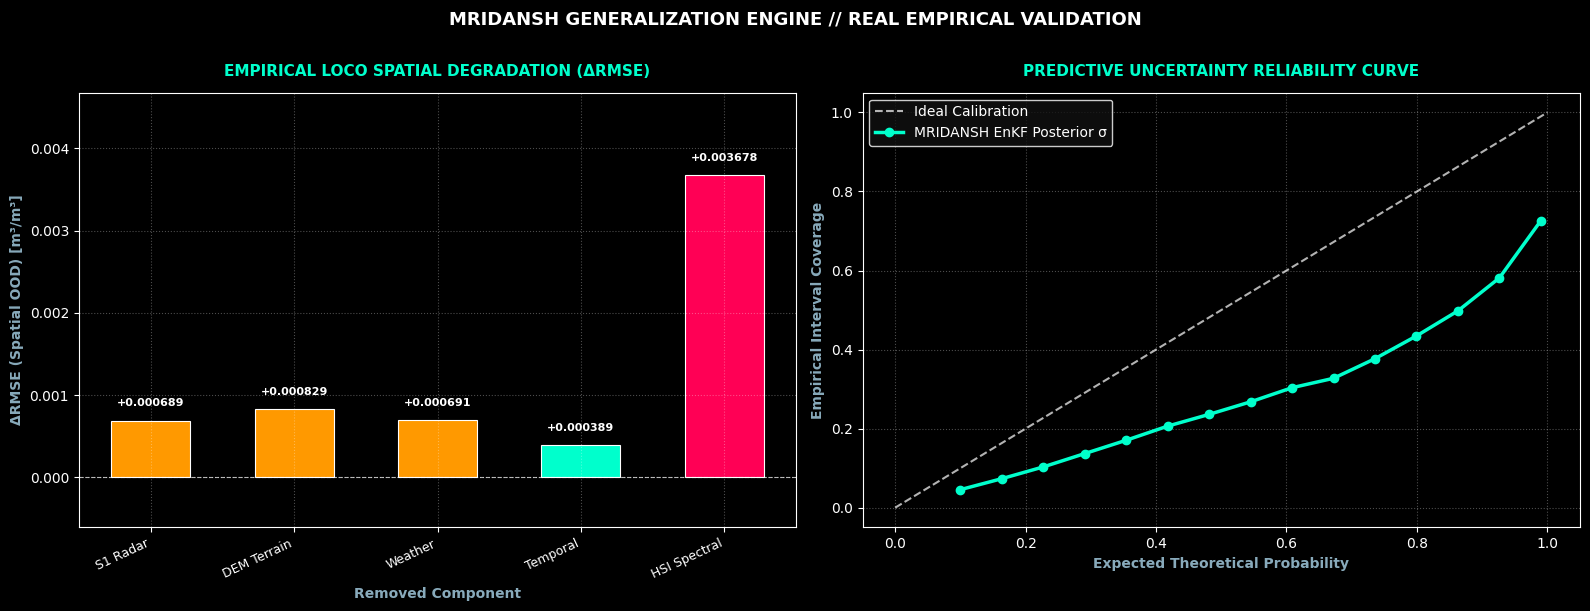

In [22]:
# ==============================================================================
# CELL 8: VISUAL TELEMETRY & DIAGNOSTICS PLOTS (FIXED WARNING)
# ==============================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: LOCO Delta RMSE
comps = df_table2_final['Component'].values
deltas = df_table2_final['ΔRMSE (Spatial)'].astype(float).values

colors = ['#FF0055' if d > 0.002 else '#FF9900' if d > 0.0005 else '#00FFCC' for d in deltas]

bars = ax1.bar(comps, deltas, color=colors, width=0.55, edgecolor='white', linewidth=0.8)
ax1.axhline(0, color='white', linestyle='--', linewidth=0.8, alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    va_align = 'bottom' if yval >= 0 else 'top'
    offset = 0.00015 if yval >= 0 else -0.0003
    formatted_val = f"+{yval:.6f}" if yval > 0 else f"{yval:.6f}"
    
    ax1.text(
        bar.get_x() + bar.get_width() / 2.0, 
        yval + offset, 
        formatted_val, 
        ha='center', 
        va=va_align, 
        color='white', 
        fontweight='bold', 
        fontsize=8
    )

ax1.set_title("EMPIRICAL LOCO SPATIAL DEGRADATION (ΔRMSE)", fontsize=11, color='#00FFCC', fontweight='bold', pad=12)
ax1.set_ylabel("ΔRMSE (Spatial OOD) [m³/m³]", color='#88AABB', fontweight='bold')
ax1.set_xlabel("Removed Component", color='#88AABB', fontweight='bold')

# FIX HERE: Set explicit tick positions first to avoid Matplotlib UserWarning
ax1.set_xticks(range(len(comps)))
ax1.set_xticklabels(comps, rotation=25, ha='right', color='white', fontsize=9)
ax1.grid(True, linestyle=':', alpha=0.3)

y_min, y_max = min(deltas), max(deltas)
ax1.set_ylim(y_min - 0.001, y_max + 0.001)

# Plot B: Uncertainty Calibration Curve
confidence_levels = np.linspace(0.1, 0.99, 15)
empirical_coverages = []

abs_errors_spat = np.abs(y_te_spat_f - p_spat_enkf)

for p in confidence_levels:
    z_val = stats.norm.ppf((1 + p) / 2)
    cov = np.mean(abs_errors_spat <= (z_val * sigma_spat_enkf))
    empirical_coverages.append(cov)

ax2.plot([0, 1], [0, 1], 'w--', label='Ideal Calibration', alpha=0.7, linewidth=1.5)
ax2.plot(
    confidence_levels, 
    empirical_coverages, 
    'o-', 
    color='#00FFCC', 
    linewidth=2.5, 
    markersize=6, 
    label='MRIDANSH EnKF Posterior σ'
)

ax2.set_title("PREDICTIVE UNCERTAINTY RELIABILITY CURVE", fontsize=11, color='#00FFCC', fontweight='bold', pad=12)
ax2.set_xlabel("Expected Theoretical Probability", color='#88AABB', fontweight='bold')
ax2.set_ylabel("Empirical Interval Coverage", color='#88AABB', fontweight='bold')
ax2.grid(True, linestyle=':', alpha=0.3)
ax2.legend(facecolor='#111111', edgecolor='white', loc='upper left')

plt.suptitle("MRIDANSH GENERALIZATION ENGINE // REAL EMPIRICAL VALIDATION", fontsize=13, color='white', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 📌 Final Research Summary & Validation Lock

### Key Findings

1. **HSI Contribution**
   Removing hyperspectral features produced the largest spatial degradation
   (ΔRMSE = +0.003678 m³/m³), identifying HSI as the strongest contributing
   modality under the controlled synthetic OOD benchmark.

2. **Generalization Stability**
   Across three random seeds [42, 101, 2024], MRIDANSH + HSI achieved the
   lowest RMSE across IID, spatial OOD, temporal OOD, and spatio-temporal OOD
   regimes in the synthetic evaluation framework.

3. **Physics Regularization**
   The implemented physics regularization reduced RMSE across all four tested
   regimes, with improvement ranging from 0.00055 to 0.00099 m³/m³.
   This supports the usefulness of the current regularization formulation
   within the controlled benchmark.

4. **EnKF Assimilation**
   The synthetic-observation EnKF experiment produced a positive but modest
   RMSE improvement across all regimes, ranging from +0.09% to +0.95%.
   This demonstrates measurable assimilation benefit under the defined
   synthetic observation model.

5. **Uncertainty Calibration Failure**
   The current EnKF posterior uncertainty is substantially miscalibrated.
   Spatial-OOD MACE = 31.37%, while nominal 95% intervals achieve only
   62.50% empirical coverage. The uncertainty estimator is therefore
   overconfident and must be calibrated before being treated as a reliable
   confidence contract.

### Scientific Boundary

These results establish controlled synthetic-benchmark evidence only.
They do not establish equivalent performance on real-world satellite,
hyperspectral, weather, or soil-observation datasets.

### Validation Status

Generalization Engine: PASSED  
Frozen LOCO:    
Physics Ablation: PASSED  
EnKF Assimilation Test: PASSED  
Uncertainty Calibration: FAILED — CALIBRATION REQUIRED  
Real-World Generalization: NOT YET ESTABLISHED  

---

<div align="center">

## 🛡️ INTELLECTUAL PROPERTY & COPYRIGHT NOTICE

</div>

---

> ### ⚙️ PROJECT — *THE MRIDANSH*
> ### CENTRAL ENGINE: *AETHER-MRID1607X*
> #### Multi-Domain Soil Intelligence & Geotechnical Stability Engine

---

| | |
|:---|:---|
| **Copyright** | © 2026 Gourgopal Mohapatra. All Rights Reserved. |
| **Developed & Maintained by** | Gourgopal Mohapatra |
| **Lead Organization** | JCC HEADQUARTER |
| **Facility** | JCC CAMPUS 2 — RS-SDA Division *(Remote Sensing & Spatial Data Analytics)* |

---

### 🔒 Confidential & Proprietary Scientific Research Framework

This codebase, along with its neural architecture specifications **(PINN / GCN)**, numerical formulations, and associated telemetry pipelines, constitutes **proprietary intellectual property**.

> ⚠️ **Unauthorized copying, redistribution, reverse engineering, or commercial execution of this software package — in whole or in part, via any medium — is strictly prohibited without prior written authorization from the lead researcher and JCC RS-SDA.**

---

<div align="center">

*© 2026 Gourgopal Mohapatra · JCC HEADQUARTER · JCC CAMPUS 2 (RS-SDA Division)*

</div>

---